# 07. ASSOCIATION RULES MINING - TÌM QUY TẮC LIÊN KẾT

## Mục Tiêu
Sử dụng **FP-Growth** để phát hiện quy tắc liên kết giữa các đặc điểm âm học và thể loại nhạc.

**Objective:**
1. Chuẩn bị dữ liệu cho association rules (categorize audio features)
2. Áp dụng FP-Growth để tìm frequent itemsets
3. Tạo association rules
4. Phân tích confidence, support, lift
5. Rút ra insights về mối quan hệ giữa các đặc điểm âm học

In [1]:
# ===== IMPORT LIBRARIES =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")
print("✅ Thư viện đã sẵn sàng")

✅ Thư viện đã sẵn sàng


In [2]:
# ===== LOAD DATA =====
print("="*100)
print("📊 TẢI DỮ LIỆU CLUSTERING")
print("="*100)

# Tải dữ liệu đã clustering
df = pd.read_csv('../data/processed/spotify_with_clusters.csv')

print(f"\n✅ Tải thành công: spotify_with_clusters.csv")
print(f"   Shape: {df.shape}")
print(f"   Rows: {len(df):,}")

# Audio features
audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 
                  'speechiness', 'acousticness', 'instrumentalness', 
                  'liveness', 'valence', 'tempo']

print(f"\n🎵 Audio Features: {audio_features}")

📊 TẢI DỮ LIỆU CLUSTERING

✅ Tải thành công: spotify_with_clusters.csv
   Shape: (11802, 307)
   Rows: 11,802

🎵 Audio Features: ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


In [3]:
# ===== CHUẨN BỊ DỮ LIỆU CHO ASSOCIATION RULES =====
print("\n" + "="*100)
print("🔧 CHUẨN BỊ DỮ LIỆU - CATEGORIZE AUDIO FEATURES")
print("="*100)

# Tạo categorical features (High/Low) dựa trên median
df_assoc = df.copy()

# Định nghĩa thresholds (median)
thresholds = {}
for feature in audio_features:
    thresholds[feature] = df[feature].median()

# Tạo binary features
for feature in audio_features:
    threshold = thresholds[feature]
    df_assoc[f'{feature}_high'] = (df[feature] >= threshold).astype(int)
    df_assoc[f'{feature}_low'] = (df[feature] < threshold).astype(int)

# Tạo transaction format (một dòng = một bài hát = một transaction)
# Lấy các features có giá trị 1 (high) cho mỗi track
transactions = []

for idx, row in df_assoc.iterrows():
    transaction = []
    
    # Thêm cluster
    transaction.append(f"cluster_{int(row['cluster'])}")
    
    # Thêm audio features (chỉ high values)
    for feature in audio_features:
        if row[f'{feature}_high'] == 1:
            transaction.append(f"{feature}_high")
    
    transactions.append(transaction)

print(f"\n✅ Tạo {len(transactions):,} transactions")
print(f"   Sample transaction: {transactions[0]}")

# Chuyển sang one-hot encoding
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\n📊 Encoded dataframe shape: {df_encoded.shape}")
print(f"   Transactions: {len(df_encoded):,}")
print(f"   Items: {len(df_encoded.columns)}")
print(f"   Items: {list(df_encoded.columns)}")


🔧 CHUẨN BỊ DỮ LIỆU - CATEGORIZE AUDIO FEATURES

✅ Tạo 11,802 transactions
   Sample transaction: ['cluster_0', 'danceability_high', 'key_high', 'mode_high', 'acousticness_high']

📊 Encoded dataframe shape: (11802, 13)
   Transactions: 11,802
   Items: 13
   Items: ['acousticness_high', 'cluster_0', 'cluster_1', 'danceability_high', 'energy_high', 'instrumentalness_high', 'key_high', 'liveness_high', 'loudness_high', 'mode_high', 'speechiness_high', 'tempo_high', 'valence_high']


In [4]:
# ===== ÁPTỤNG FP-GROWTH =====
print("\n" + "="*100)
print("🔍 ÁP DỤNG FP-GROWTH - TÌM FREQUENT ITEMSETS")
print("="*100)

# FP-Growth với support thấp để tìm được nhiều patterns
min_support = 0.05  # 5% support
print(f"\n🎯 Minimum Support: {min_support*100}%")

frequent_itemsets = fpgrowth(df_encoded, min_support=min_support, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print(f"\n✅ Tìm được {len(frequent_itemsets):,} frequent itemsets")
print(f"   Itemset sizes:")
print(frequent_itemsets['length'].value_counts().sort_index())

# Hiển thị top 20 itemsets với support cao nhất
print(f"\n📊 Top 20 Frequent Itemsets:")
top_itemsets = frequent_itemsets.nlargest(20, 'support')
for idx, row in top_itemsets.iterrows():
    print(f"   {list(row['itemsets'])}: Support={row['support']:.4f}")


🔍 ÁP DỤNG FP-GROWTH - TÌM FREQUENT ITEMSETS

🎯 Minimum Support: 5.0%

✅ Tìm được 2,173 frequent itemsets
   Itemset sizes:
length
1     13
2     74
3    236
4    482
5    612
6    476
7    221
8     54
9      5
Name: count, dtype: int64

📊 Top 20 Frequent Itemsets:
   ['mode_high']: Support=1.0000
   ['cluster_0']: Support=0.6999
   ['cluster_0', 'mode_high']: Support=0.6999
   ['key_high']: Support=0.5680
   ['mode_high', 'key_high']: Support=0.5680
   ['valence_high']: Support=0.5122
   ['valence_high', 'mode_high']: Support=0.5122
   ['acousticness_high']: Support=0.5086
   ['acousticness_high', 'mode_high']: Support=0.5086
   ['liveness_high']: Support=0.5068
   ['liveness_high', 'mode_high']: Support=0.5068
   ['danceability_high']: Support=0.5008
   ['mode_high', 'danceability_high']: Support=0.5008
   ['tempo_high']: Support=0.5003
   ['tempo_high', 'mode_high']: Support=0.5003
   ['instrumentalness_high']: Support=0.5002
   ['mode_high', 'instrumentalness_high']: Support=0.500

In [5]:
# ===== TẠO ASSOCIATION RULES =====
print("\n" + "="*100)
print("🔗 TẠO ASSOCIATION RULES")
print("="*100)

# Tạo association rules từ frequent itemsets
min_confidence = 0.3  # Confidence >= 30%
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

print(f"\n✅ Tạo {len(rules):,} association rules")
print(f"   Minimum Confidence: {min_confidence*100}%")

# Tính toán thêm metrics
rules['antecedent_len'] = rules['antecedents'].apply(lambda x: len(x))
rules['consequent_len'] = rules['consequents'].apply(lambda x: len(x))

# Sắp xếp theo lift (chỉ số thú vị nhất)
rules = rules.sort_values('lift', ascending=False)

print(f"\n📊 Top 20 Association Rules (Sort by Lift):")
top_rules = rules.head(20)
for idx, row in top_rules.iterrows():
    antecedents = ' AND '.join(list(row['antecedents']))
    consequents = ' AND '.join(list(row['consequents']))
    print(f"\n   {antecedents} => {consequents}")
    print(f"      Support: {row['support']:.4f} | Confidence: {row['confidence']:.4f} | Lift: {row['lift']:.4f}")


🔗 TẠO ASSOCIATION RULES

✅ Tạo 61,096 association rules
   Minimum Confidence: 30.0%

📊 Top 20 Association Rules (Sort by Lift):

   valence_high AND liveness_high AND danceability_high AND loudness_high => acousticness_high AND cluster_0 AND mode_high AND speechiness_high AND energy_high
      Support: 0.0576 | Confidence: 0.3503 | Lift: 3.8213

   liveness_high AND mode_high AND valence_high AND loudness_high AND danceability_high => acousticness_high AND cluster_0 AND energy_high AND speechiness_high
      Support: 0.0576 | Confidence: 0.3503 | Lift: 3.8213

   valence_high AND liveness_high AND danceability_high AND loudness_high => acousticness_high AND cluster_0 AND energy_high AND speechiness_high
      Support: 0.0576 | Confidence: 0.3503 | Lift: 3.8213

   acousticness_high AND cluster_0 AND energy_high AND speechiness_high => valence_high AND liveness_high AND danceability_high AND loudness_high
      Support: 0.0576 | Confidence: 0.6285 | Lift: 3.8213

   acousticness_high 


📊 VISUALIZATION: SUPPORT vs CONFIDENCE vs LIFT


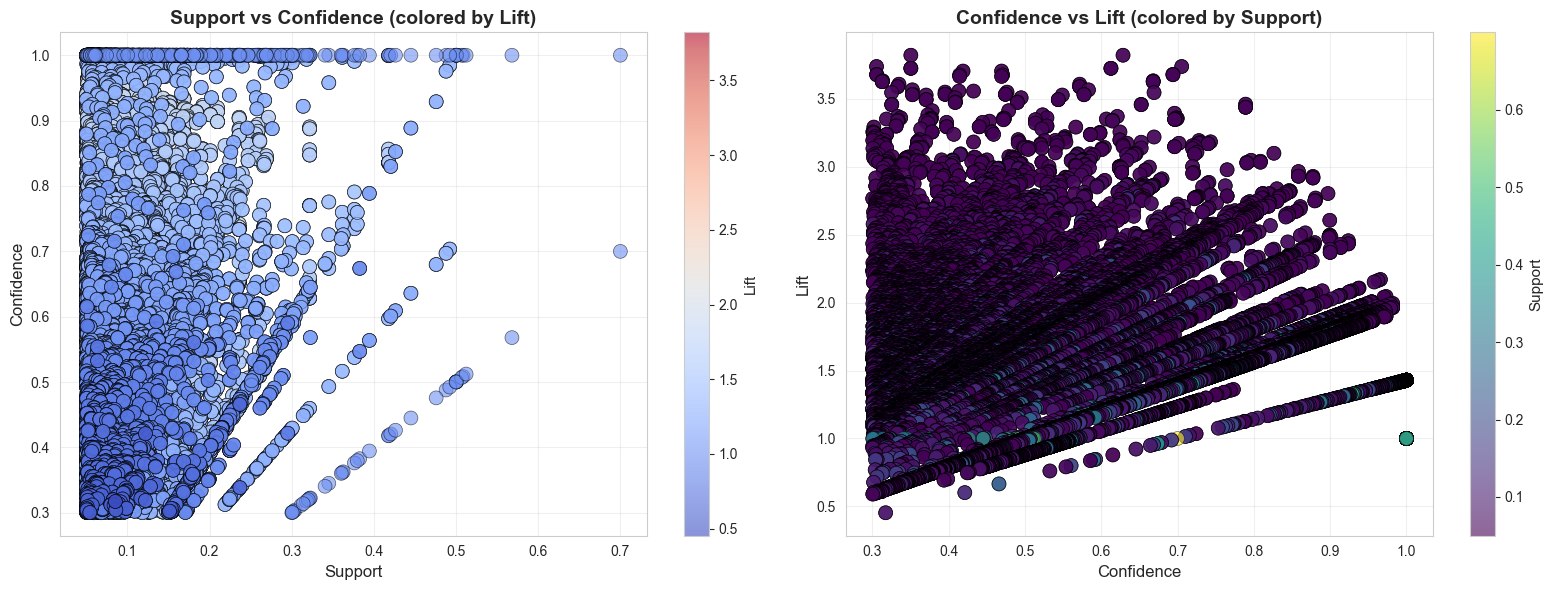

✅ Visualization hoàn tất


In [6]:
# ===== VISUALIZATION: SCATTER PLOT (SUPPORT vs CONFIDENCE vs LIFT) =====
print("\n" + "="*100)
print("📊 VISUALIZATION: SUPPORT vs CONFIDENCE vs LIFT")
print("="*100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Support vs Confidence (color = Lift)
scatter1 = ax1.scatter(rules['support'], rules['confidence'], 
                       c=rules['lift'], s=100, cmap='coolwarm', 
                       alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Support', fontsize=12)
ax1.set_ylabel('Confidence', fontsize=12)
ax1.set_title('Support vs Confidence (colored by Lift)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Lift', fontsize=11)

# Plot 2: Confidence vs Lift (color = Support)
scatter2 = ax2.scatter(rules['confidence'], rules['lift'],
                       c=rules['support'], s=100, cmap='viridis',
                       alpha=0.6, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Confidence', fontsize=12)
ax2.set_ylabel('Lift', fontsize=12)
ax2.set_title('Confidence vs Lift (colored by Support)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Support', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/figures/association_rules_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization hoàn tất")

In [7]:
# ===== INSIGHTS RÚT RA TỪ ASSOCIATION RULES =====
print("\n" + "="*100)
print("💡 INSIGHTS RÚT RA TỪ ASSOCIATION RULES")
print("="*100)

# 1. Những patterns nổi bật nhất (Lift cao)
print("\n🔥 Top 10 STRONGEST RULES (Highest Lift):")
print("   " + "-"*80)
for idx, (i, row) in enumerate(rules.head(10).iterrows(), 1):
    antecedents = ' AND '.join(list(row['antecedents']))
    consequents = ' AND '.join(list(row['consequents']))
    
    print(f"\n   {idx}. IF {antecedents}")
    print(f"      THEN {consequents}")
    print(f"         Support: {row['support']:.2%} | Confidence: {row['confidence']:.2%} | Lift: {row['lift']:.2f}x")
    
    # Interpretation
    if row['lift'] > 2:
        print(f"         ⭐ VERY STRONG: Xảy ra gấp {row['lift']:.1f}x thường xuyên hơn")
    elif row['lift'] > 1.5:
        print(f"         ✨ STRONG: Xảy ra gấp {row['lift']:.1f}x thường xuyên hơn")
    else:
        print(f"         • MODERATE: Xảy ra gấp {row['lift']:.1f}x thường xuyên hơn")

# 2. Rules liên quan đến clusters
print("\n\n🎯 TOP RULES LIÊN QUAN CLUSTER:")
print("   " + "-"*80)
cluster_rules = rules[rules['antecedents'].apply(lambda x: any('cluster' in str(item) for item in x)) | 
                      rules['consequents'].apply(lambda x: any('cluster' in str(item) for item in x))]

for idx, (i, row) in enumerate(cluster_rules.head(5).iterrows(), 1):
    antecedents = ' AND '.join(list(row['antecedents']))
    consequents = ' AND '.join(list(row['consequents']))
    
    print(f"\n   {idx}. {antecedents} => {consequents}")
    print(f"      Confidence: {row['confidence']:.2%} | Lift: {row['lift']:.2f}")


💡 INSIGHTS RÚT RA TỪ ASSOCIATION RULES

🔥 Top 10 STRONGEST RULES (Highest Lift):
   --------------------------------------------------------------------------------

   1. IF valence_high AND liveness_high AND danceability_high AND loudness_high
      THEN acousticness_high AND cluster_0 AND mode_high AND speechiness_high AND energy_high
         Support: 5.76% | Confidence: 35.03% | Lift: 3.82x
         ⭐ VERY STRONG: Xảy ra gấp 3.8x thường xuyên hơn

   2. IF liveness_high AND mode_high AND valence_high AND loudness_high AND danceability_high
      THEN acousticness_high AND cluster_0 AND energy_high AND speechiness_high
         Support: 5.76% | Confidence: 35.03% | Lift: 3.82x
         ⭐ VERY STRONG: Xảy ra gấp 3.8x thường xuyên hơn

   3. IF valence_high AND liveness_high AND danceability_high AND loudness_high
      THEN acousticness_high AND cluster_0 AND energy_high AND speechiness_high
         Support: 5.76% | Confidence: 35.03% | Lift: 3.82x
         ⭐ VERY STRONG: Xảy ra g

In [8]:
# ===== THỐNG KÊ ITEMSETS VÀ RULES =====
print("\n" + "="*100)
print("📈 THỐNG KÊ VỀ ITEMSETS VÀ RULES")
print("="*100)

print(f"\n📊 FREQUENT ITEMSETS STATISTICS:")
print(f"   Tổng itemsets: {len(frequent_itemsets):,}")
print(f"   - Size 1: {len(frequent_itemsets[frequent_itemsets['length'] == 1]):,}")
print(f"   - Size 2: {len(frequent_itemsets[frequent_itemsets['length'] == 2]):,}")
print(f"   - Size 3: {len(frequent_itemsets[frequent_itemsets['length'] == 3]):,}")
print(f"   - Size 4+: {len(frequent_itemsets[frequent_itemsets['length'] >= 4]):,}")

print(f"\n🔗 ASSOCIATION RULES STATISTICS:")
print(f"   Tổng rules: {len(rules):,}")
print(f"   Avg Support: {rules['support'].mean():.4f}")
print(f"   Avg Confidence: {rules['confidence'].mean():.4f}")
print(f"   Avg Lift: {rules['lift'].mean():.4f}")

# Rules với Lift > 1 (interesting rules)
interesting_rules = rules[rules['lift'] > 1]
print(f"\n   Rules với Lift > 1: {len(interesting_rules):,} ({len(interesting_rules)/len(rules)*100:.1f}%)")

# Rules với Lift > 1.5 (very interesting)
very_interesting = rules[rules['lift'] > 1.5]
print(f"   Rules với Lift > 1.5: {len(very_interesting):,} ({len(very_interesting)/len(rules)*100:.1f}%)")

print(f"\n📊 CONFIDENCE DISTRIBUTION:")
print(rules['confidence'].describe())


📈 THỐNG KÊ VỀ ITEMSETS VÀ RULES

📊 FREQUENT ITEMSETS STATISTICS:
   Tổng itemsets: 2,173
   - Size 1: 13
   - Size 2: 74
   - Size 3: 236
   - Size 4+: 1,850

🔗 ASSOCIATION RULES STATISTICS:
   Tổng rules: 61,096
   Avg Support: 0.0937
   Avg Confidence: 0.5491
   Avg Lift: 1.7005

   Rules với Lift > 1: 56,619 (92.7%)
   Rules với Lift > 1.5: 38,550 (63.1%)

📊 CONFIDENCE DISTRIBUTION:
count    61096.000000
mean         0.549137
std          0.189596
min          0.300000
25%          0.390650
50%          0.506828
75%          0.673215
max          1.000000
Name: confidence, dtype: float64


In [9]:
# ===== LƯU KẾT QUẢ ASSOCIATION RULES =====
print("\n" + "="*100)
print("💾 LƯU KẾT QUẢ ASSOCIATION RULES")
print("="*100)

# Chuyển frozensets thành strings để lưu
rules_export = rules.copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ','.join(list(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ','.join(list(x)))

# Lưu top rules
rules_file = '../outputs/association_rules_top50.csv'
rules_export.head(50).to_csv(rules_file, index=False)

print(f"\n✅ Lưu Top 50 Rules: {rules_file}")

# Lưu frequent itemsets
itemsets_export = frequent_itemsets.copy()
itemsets_export['itemsets'] = itemsets_export['itemsets'].apply(lambda x: ','.join(list(x)))

itemsets_file = '../outputs/frequent_itemsets.csv'
itemsets_export.to_csv(itemsets_file, index=False)

print(f"✅ Lưu Frequent Itemsets: {itemsets_file}")

print("\n" + "="*100)
print("🎉 ASSOCIATION RULES ANALYSIS HOÀN TẤT!")
print("="*100)


💾 LƯU KẾT QUẢ ASSOCIATION RULES

✅ Lưu Top 50 Rules: ../outputs/association_rules_top50.csv
✅ Lưu Frequent Itemsets: ../outputs/frequent_itemsets.csv

🎉 ASSOCIATION RULES ANALYSIS HOÀN TẤT!
